# Map projection figures

This notebook regenerates figures for the map-projection writeup. The first cell below redraws `Figure1` using only Python, `matplotlib`, and the local `triangulated-land.json` data.

In [1]:
from pathlib import Path
import json
import math
import os

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle, FancyArrowPatch, Polygon, Rectangle

ROOT = Path.cwd()
if ROOT.name != "newFigures":
    root_guess = ROOT / "writ" / "MapProjection" / "newFigures"
    if root_guess.exists():
        ROOT = root_guess
    else:
        raise RuntimeError("Run this notebook from writ/MapProjection/newFigures or the repository root.")

MAP_PROJECTION_DIR = ROOT if ROOT.name == "MapProjection" else ROOT.parent
if ROOT.name == "newFigures":
    MAP_PROJECTION_DIR = ROOT.parent

DATA_DIR = MAP_PROJECTION_DIR / "data"
OUT_DIR = MAP_PROJECTION_DIR / "newFigures"
OUT_DIR.mkdir(exist_ok=True)

# Keeping the matplotlib cache local avoids permissions warnings on this machine.
mpl_cache = OUT_DIR / ".mplcache"
mpl_cache.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_cache))

with open(DATA_DIR / "triangulated-land.json") as f:
    land = json.load(f)

pts_groups = [[tuple(pt[:2]) for pt in group] for group in land["pts"]]
tri_groups = land["triangles"]

lon0 = math.radians(-25)
lat0 = math.radians(20)
min_map_lat = math.radians(-55)
max_map_lat = math.radians(83)
merc_min = math.log(math.tan(math.pi / 4 + min_map_lat / 2))
merc_max = math.log(math.tan(math.pi / 4 + max_map_lat / 2))
min_map_lon = math.radians(-178)
max_map_lon = math.radians(178)
min_land_lat = math.radians(-60)

water = "#cfe6f7"
map_bg = "#e8eef3"
land_color = "#8b947f"
grid_color = "#7a8793"
edge_color = "#5f6d77"

fig = plt.figure(figsize=(12, 6.7), dpi=180)
ax = plt.axes([0, 0, 1, 1])
ax.set_xlim(0, 12)
ax.set_ylim(0, 6.7)
ax.set_aspect("equal")
ax.axis("off")

# Overall layout of the composition.
cx, cy, R = 2.7, 3.35, 1.75
mx0, my0, mw, mh = 6.5, 1.2, 5.25, 4.1

def ortho_project(lon, lat, lon0=lon0, lat0=lat0):
    dl = lon - lon0
    cosc = (
        math.sin(lat0) * math.sin(lat)
        + math.cos(lat0) * math.cos(lat) * math.cos(dl)
    )
    x = math.cos(lat) * math.sin(dl)
    y = (
        math.cos(lat0) * math.sin(lat)
        - math.sin(lat0) * math.cos(lat) * math.cos(dl)
    )
    return x, y, cosc

def mercator_xy(lon, lat, lon0=lon0):
    lonr = ((lon - lon0 + math.pi) % (2 * math.pi)) - math.pi
    lonr = max(min_map_lon, min(max_map_lon, lonr))
    latc = max(min_map_lat, min(max_map_lat, lat))
    x = mx0 + (lonr - min_map_lon) / (max_map_lon - min_map_lon) * mw
    y_merc = math.log(math.tan(math.pi / 4 + latc / 2))
    y = my0 + (y_merc - merc_min) / (merc_max - merc_min) * mh
    return x, y

# Globe background.
ax.add_patch(Circle((cx, cy), R, facecolor=water, edgecolor=edge_color, linewidth=1.4, zorder=1))

# A soft highlight keeps the globe from looking too flat.
N = 500
xs = np.linspace(cx - R, cx + R, N)
ys = np.linspace(cy - R, cy + R, N)
X, Y = np.meshgrid(xs, ys)
rx = (X - cx) / R
ry = (Y - cy) / R
mask = rx**2 + ry**2 <= 1
shade = 0.82 + 0.18 * np.clip(1 - 0.5 * rx - 0.9 * ry, 0, 1)
img = np.ones((N, N, 4))
base = np.array([0xCF, 0xE6, 0xF7]) / 255
for i in range(3):
    img[:, :, i] = np.clip(base[i] * shade, 0, 1)
img[:, :, 3] = mask.astype(float)
ax.imshow(
    img,
    extent=[cx - R, cx + R, cy - R, cy + R],
    origin="lower",
    zorder=1.1,
)

# Globe graticule.
for lon_deg in range(-165, 166, 15):
    seg = []
    for lat_deg in np.linspace(-89.5, 89.5, 320):
        x, y, cosc = ortho_project(math.radians(lon_deg), math.radians(lat_deg))
        if cosc >= 0:
            seg.append((cx + R * x, cy + R * y))
        elif len(seg) > 1:
            ax.plot(*zip(*seg), color=grid_color, lw=0.55, alpha=0.6, zorder=2)
            seg = []
    if len(seg) > 1:
        ax.plot(*zip(*seg), color=grid_color, lw=0.55, alpha=0.6, zorder=2)

for lat_deg in range(-75, 76, 15):
    seg = []
    for lon_deg in np.linspace(-180, 180, 500):
        x, y, cosc = ortho_project(math.radians(lon_deg), math.radians(lat_deg))
        if cosc >= 0:
            seg.append((cx + R * x, cy + R * y))
        elif len(seg) > 1:
            ax.plot(*zip(*seg), color=grid_color, lw=0.55, alpha=0.6, zorder=2)
            seg = []
    if len(seg) > 1:
        ax.plot(*zip(*seg), color=grid_color, lw=0.55, alpha=0.6, zorder=2)

# Globe land masses from the triangulated data.
triangles = []
for pts, tri_list in zip(pts_groups, tri_groups):
    proj = [ortho_project(lon, lat) for lon, lat in pts]
    for tri in tri_list:
        verts = [proj[i] for i in tri]
        if any(v[2] < 0 for v in verts):
            continue
        depth = sum(v[2] for v in verts) / 3
        poly = [(cx + R * v[0], cy + R * v[1]) for v in verts]
        triangles.append((depth, poly))

triangles.sort(key=lambda item: item[0])
ax.add_collection(
    PatchCollection(
        [Polygon(poly, closed=True) for _, poly in triangles],
        facecolor=land_color,
        edgecolor="none",
        zorder=3,
    )
)
ax.add_patch(Circle((cx, cy), R, facecolor="none", edgecolor=edge_color, linewidth=1.4, zorder=4))

# Arrow from the globe to the flattened map.
ax.add_patch(
    FancyArrowPatch(
        (5.0, 3.35),
        (6.2, 3.35),
        arrowstyle="Simple,head_length=16,head_width=12,tail_width=1.5",
        color="black",
        lw=0,
        zorder=5,
    )
)

# Mercator panel.
ax.add_patch(Rectangle((mx0, my0), mw, mh, facecolor=map_bg, edgecolor="none", zorder=0.5))

for lon_deg in range(-180, 181, 15):
    x, _ = mercator_xy(math.radians(lon_deg) + lon0, 0)
    ax.plot([x, x], [my0, my0 + mh], color=grid_color, lw=0.8, alpha=0.7, zorder=1)

for lat_deg in range(-75, 76, 15):
    _, y = mercator_xy(0, math.radians(lat_deg))
    ax.plot([mx0, mx0 + mw], [y, y], color=grid_color, lw=0.8, alpha=0.7, zorder=1)

for pts, tri_list in zip(pts_groups, tri_groups):
    for tri in tri_list:
        lons = []
        lats = []
        for i in tri:
            lon, lat = pts[i]
            if lat < min_land_lat:
                lats = []
                break
            lons.append(((lon - lon0 + math.pi) % (2 * math.pi)) - math.pi)
            lats.append(max(min_map_lat, min(max_map_lat, lat)))
        if not lats:
            continue
        if max(lons) - min(lons) > math.pi:
            continue
        poly = [mercator_xy(lon + lon0, lat) for lon, lat in zip(lons, lats)]
        ax.add_patch(Polygon(poly, closed=True, facecolor=land_color, edgecolor="none", zorder=2.5))

ax.add_patch(Rectangle((mx0, my0), mw, mh, facecolor="none", edgecolor=edge_color, linewidth=1.1, zorder=4))

png_path = OUT_DIR / "Figure1.png"
pdf_path = OUT_DIR / "Figure1.pdf"
fig.savefig(png_path, dpi=220, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
plt.close(fig)

print(f"Saved {png_path}")
print(f"Saved {pdf_path}")

Saved /Users/mcmcclur/GitHubDocuments/MarksMath/writ/MapProjection/newFigures/Figure1.png
Saved /Users/mcmcclur/GitHubDocuments/MarksMath/writ/MapProjection/newFigures/Figure1.pdf


## Figure 4

This figure uses two rhumb lines intersecting at a chosen point on the sphere. In the Mercator panel those rhumb lines become straight lines and preserve their angle, while the equirectangular panel distorts that angle.

In [ ]:
fig = plt.figure(figsize=(8, 8), dpi=180)
ax = plt.axes([0, 0, 1, 1])
ax.set_xlim(0, 8)
ax.set_ylim(0, 8)
ax.set_aspect("equal")
ax.axis("off")

cx, cy, R = 4.0, 5.5, 1.7
left_panel = (0.6, 0.6, 2.8, 2.0)
right_panel = (4.6, 0.6, 2.8, 2.0)

edge = "#677785"
grid = "#8796a3"
water = "#d9edf9"
curve = "#111111"

ax.add_patch(Circle((cx, cy), R, facecolor=water, edgecolor=edge, linewidth=1.2))

def ortho4(lon, lat, lon0=math.radians(28), lat0=math.radians(30)):
    dl = lon - lon0
    cosc = math.sin(lat0) * math.sin(lat) + math.cos(lat0) * math.cos(lat) * math.cos(dl)
    x = math.cos(lat) * math.sin(dl)
    y = math.cos(lat0) * math.sin(lat) - math.sin(lat0) * math.cos(lat) * math.cos(dl)
    return x, y, cosc

for lon_deg in range(-180, 181, 10):
    seg = []
    for lat_deg in np.linspace(-89, 89, 300):
        x, y, cosc = ortho4(math.radians(lon_deg), math.radians(lat_deg))
        if cosc >= 0:
            seg.append((cx + R * x, cy + R * y))
        elif len(seg) > 1:
            ax.plot(*zip(*seg), color=grid, lw=0.5, alpha=0.55)
            seg = []
    if len(seg) > 1:
        ax.plot(*zip(*seg), color=grid, lw=0.5, alpha=0.55)

for lat_deg in range(-80, 81, 10):
    seg = []
    for lon_deg in np.linspace(-180, 180, 400):
        x, y, cosc = ortho4(math.radians(lon_deg), math.radians(lat_deg))
        if cosc >= 0:
            seg.append((cx + R * x, cy + R * y))
        elif len(seg) > 1:
            ax.plot(*zip(*seg), color=grid, lw=0.5, alpha=0.55)
            seg = []
    if len(seg) > 1:
        ax.plot(*zip(*seg), color=grid, lw=0.5, alpha=0.55)

for x0, y0, w, h in [left_panel, right_panel]:
    ax.add_patch(Rectangle((x0, y0), w, h, facecolor="white", edgecolor="none"))

min_fig4_lat = math.radians(-60)
max_fig4_lat = math.radians(85)
merc4_min = math.log(math.tan(math.pi / 4 + min_fig4_lat / 2))
merc4_max = math.log(math.tan(math.pi / 4 + max_fig4_lat / 2))
min_fig4_lon = math.radians(-178)
max_fig4_lon = math.radians(178)

def mercator_panel4(lon, lat, panel):
    x0, y0, w, h = panel
    lonr = ((lon + math.pi) % (2 * math.pi)) - math.pi
    lonr = max(min_fig4_lon, min(max_fig4_lon, lonr))
    lat = max(min_fig4_lat, min(max_fig4_lat, lat))
    y = math.log(math.tan(math.pi / 4 + lat / 2))
    X = x0 + (lonr - min_fig4_lon) / (max_fig4_lon - min_fig4_lon) * w
    Y = y0 + (y - merc4_min) / (merc4_max - merc4_min) * h
    return X, Y

def equirect_panel4(lon, lat, panel):
    x0, y0, w, h = panel
    lonr = ((lon + math.pi) % (2 * math.pi)) - math.pi
    lonr = max(min_fig4_lon, min(max_fig4_lon, lonr))
    lat = max(min_fig4_lat, min(max_fig4_lat, lat))
    X = x0 + (lonr - min_fig4_lon) / (max_fig4_lon - min_fig4_lon) * w
    Y = y0 + (lat - min_fig4_lat) / (max_fig4_lat - min_fig4_lat) * h
    return X, Y

for panel, proj in [(left_panel, equirect_panel4), (right_panel, mercator_panel4)]:
    for lon_deg in range(-170, 171, 10):
        xs = []
        ys = []
        for lat_deg in np.linspace(math.degrees(min_fig4_lat), math.degrees(max_fig4_lat), 150):
            X, Y = proj(math.radians(lon_deg), math.radians(lat_deg), panel)
            xs.append(X)
            ys.append(Y)
        ax.plot(xs, ys, color=grid, lw=0.4, alpha=0.55)
    for lat_deg in range(-50, 81, 10):
        xs = []
        ys = []
        for lon_deg in np.linspace(-178, 178, 200):
            X, Y = proj(math.radians(lon_deg), math.radians(lat_deg), panel)
            xs.append(X)
            ys.append(Y)
        ax.plot(xs, ys, color=grid, lw=0.4, alpha=0.55)

path1 = [(math.radians(t), math.radians(90 * math.sin(math.radians(t)))) for t in range(-80, 81)]
path2 = [(math.radians(t - 15), math.radians(90 * math.cos(math.radians(t)))) for t in range(10, 171)]

for path in [path1, path2]:
    lons = []
    lats = []
    for lon, lat in path:
        if min_fig4_lat <= lat <= max_fig4_lat:
            lons.append(lon)
            lats.append(lat)

    xm = []
    ym = []
    xe = []
    ye = []
    for lon, lat in zip(lons, lats):
        X, Y = mercator_panel4(lon, lat, right_panel)
        xm.append(X)
        ym.append(Y)
        X, Y = equirect_panel4(lon, lat, left_panel)
        xe.append(X)
        ye.append(Y)

    ax.plot(xm, ym, color=curve, lw=2.0)
    ax.plot(xe, ye, color=curve, lw=2.0)

    seg = []
    for lon, lat in zip(lons, lats):
        x, y, cosc = ortho4(lon, lat)
        if cosc >= 0:
            seg.append((cx + R * x, cy + R * y))
        elif len(seg) > 1:
            ax.plot(*zip(*seg), color=curve, lw=2.0)
            seg = []
    if len(seg) > 1:
        ax.plot(*zip(*seg), color=curve, lw=2.0)

ax.add_patch(Circle((cx, cy), R, facecolor="none", edgecolor=edge, linewidth=1.2))

png_path = OUT_DIR / "Figure4.png"
pdf_path = OUT_DIR / "Figure4.pdf"
fig.savefig(png_path, dpi=220, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
plt.close(fig)

print(f"Saved {png_path}")
print(f"Saved {pdf_path}")

## Figure 5

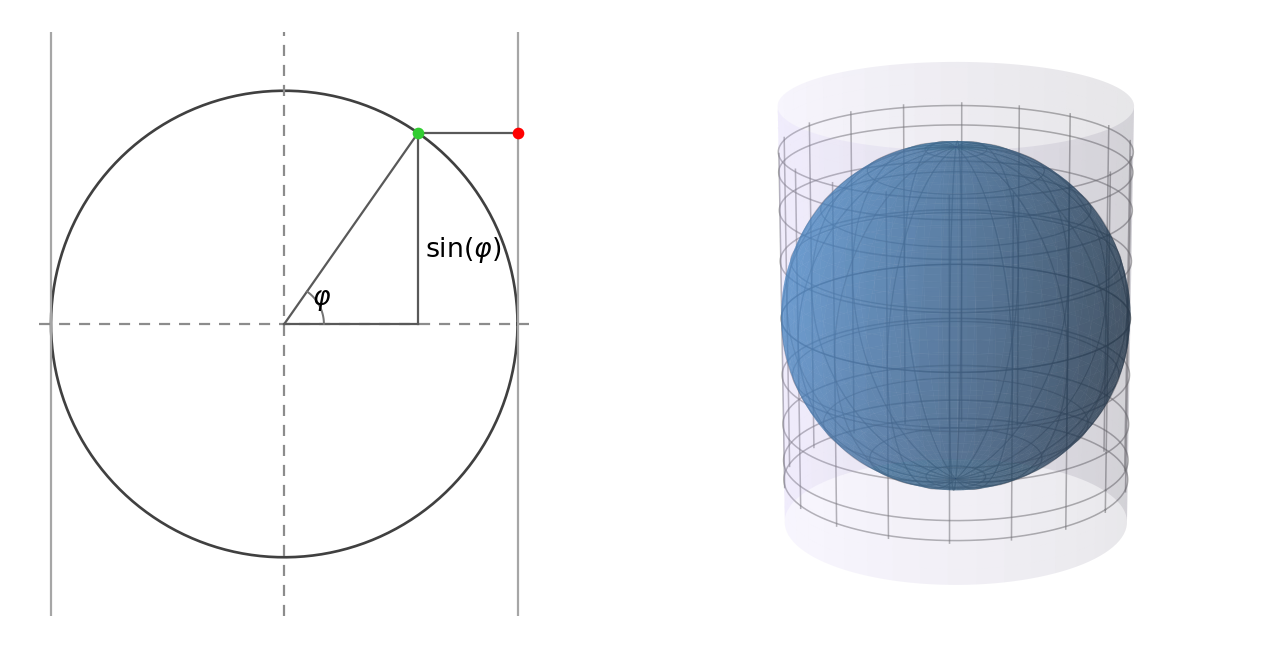

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


# ------------------------------------------------------------
# Geometry
# ------------------------------------------------------------

R = 1.0  # sphere radius

# A sample latitude for the left-hand construction
phi = np.deg2rad(55)

# Point on the unit circle in the x-z cross section
# Using x = cos(phi), z = sin(phi)
px = np.cos(phi)
pz = np.sin(phi)


# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------

fig = plt.figure(figsize=(10, 5), dpi=160)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.15], wspace=0.15)

ax2d = fig.add_subplot(gs[0, 0])
ax3d = fig.add_subplot(gs[0, 1], projection="3d")


# ------------------------------------------------------------
# Left panel: 2D cross-section
# ------------------------------------------------------------

t = np.linspace(0, 2 * np.pi, 500)
xc = np.cos(t)
zc = np.sin(t)

# Circle (cross-section of globe)
ax2d.plot(xc, zc, color="0.25", lw=1.2)

# Tangent lines (cross-section of cylinder)
ax2d.plot([1, 1], [-1.25, 1.25], color="0.65", lw=1.0)
ax2d.plot([-1, -1], [-1.25, 1.25], color="0.65", lw=1.0)

# Dashed axes
ax2d.plot([0, 0], [-1.25, 1.25], ls=(0, (5, 4)), color="0.55", lw=1.0)
ax2d.plot([-1.05, 1.05], [0, 0], ls=(0, (5, 4)), color="0.55", lw=1.0)

# Radius to point
ax2d.plot([0, px], [0, pz], color="0.35", lw=1.0)

# Vertical side of right triangle
ax2d.plot([px, px], [0, pz], color="0.35", lw=1.0)

# Small horizontal side
ax2d.plot([0, px], [0, 0], color="0.35", lw=1.0)

# Horizontal projection to cylinder
ax2d.plot([px, 1], [pz, pz], color="0.35", lw=1.0)

# Mark points
ax2d.scatter([px], [pz], color="limegreen", s=18, zorder=5)
ax2d.scatter([1], [pz], color="red", s=18, zorder=5)

# Little angle arc for phi
ang = np.linspace(0, phi, 100)
r_arc = 0.17
ax2d.plot(r_arc * np.cos(ang), r_arc * np.sin(ang), color="0.45", lw=0.9)
ax2d.text(0.12, 0.08, r"$\varphi$", fontsize=12)

# Label sin(phi)
ax2d.text(px + 0.03, 0.35 * pz, r"$\sin(\varphi)$", fontsize=12)

ax2d.set_aspect("equal")
ax2d.set_xlim(-1.15, 1.15)
ax2d.set_ylim(-1.25, 1.25)
ax2d.axis("off")


# ------------------------------------------------------------
# Right panel: sphere + cylinder + projected graticule
# ------------------------------------------------------------

# Sphere surface
u = np.linspace(0, 2 * np.pi, 120)
v = np.linspace(-np.pi / 2, np.pi / 2, 80)
U, V = np.meshgrid(u, v)

Xs = np.cos(V) * np.cos(U)
Ys = np.cos(V) * np.sin(U)
Zs = np.sin(V)

ax3d.plot_surface(
    Xs, Ys, Zs,
    rstride=2, cstride=2,
    linewidth=0,
    alpha=0.5,
    shade=True
)

# Cylinder surface x^2 + y^2 = 1
theta = np.linspace(0, 2 * np.pi, 120)
z = np.linspace(-1.25, 1.25, 80)
Theta, Zc = np.meshgrid(theta, z)

Xc = np.cos(Theta)
Yc = np.sin(Theta)

ax3d.plot_surface(
    Xc, Yc, Zc,
    rstride=3, cstride=3,
    color="#c9b7ff",
    alpha=0.12,
    linewidth=0
)

# Graticule on sphere:
# meridians = lambda constant
# parallels = phi constant
lons = np.deg2rad(np.arange(0, 360, 20))
lats = np.deg2rad(np.arange(-80, 81, 20))

tt = np.linspace(-np.pi / 2, np.pi / 2, 300)
pp = np.linspace(0, 2 * np.pi, 400)

# Sphere meridians
for lam in lons:
    x = np.cos(tt) * np.cos(lam)
    y = np.cos(tt) * np.sin(lam)
    z = np.sin(tt)
    ax3d.plot(x, y, z, color="0.55", lw=0.6, alpha=0.65)

# Sphere parallels
for lat in lats:
    x = np.cos(lat) * np.cos(pp)
    y = np.cos(lat) * np.sin(pp)
    z = np.sin(lat) * np.ones_like(pp)
    ax3d.plot(x, y, z, color="0.55", lw=0.6, alpha=0.65)

# Lambert cylindrical equal-area image on cylinder:
# (lambda, phi) -> (cos lambda, sin lambda, sin phi) on the tangent cylinder
for lam in lons:
    z = np.sin(tt)
    x = np.cos(lam) * np.ones_like(tt)
    y = np.sin(lam) * np.ones_like(tt)
    ax3d.plot(x, y, z, color="0.45", lw=0.7, alpha=0.55)

for lat in lats:
    z = np.sin(lat) * np.ones_like(pp)
    x = np.cos(pp)
    y = np.sin(pp)
    ax3d.plot(x, y, z, color="0.45", lw=0.7, alpha=0.55)

# Make the globe look tall, like the source figure
# ax3d.set_box_aspect((1, 1, 2.2))
lim = 1.25
ax3d.set_xlim(-lim, lim)
ax3d.set_ylim(-lim, lim)
ax3d.set_zlim(-lim, lim)

ax3d.set_box_aspect((1, 1, 1))
ax3d.view_init(elev=18, azim=-58)

# Clean 3D axes
ax3d.set_xlim(-1.05, 1.05)
ax3d.set_ylim(-1.05, 1.05)
ax3d.set_zlim(-1.05, 1.05)
ax3d.set_axis_off()

# Save high-quality PNG
fig.savefig("Figure5.png", dpi=300, bbox_inches="tight")

# Save vector PDF
fig.savefig("Figure5.pdf", bbox_inches="tight")

plt.show()

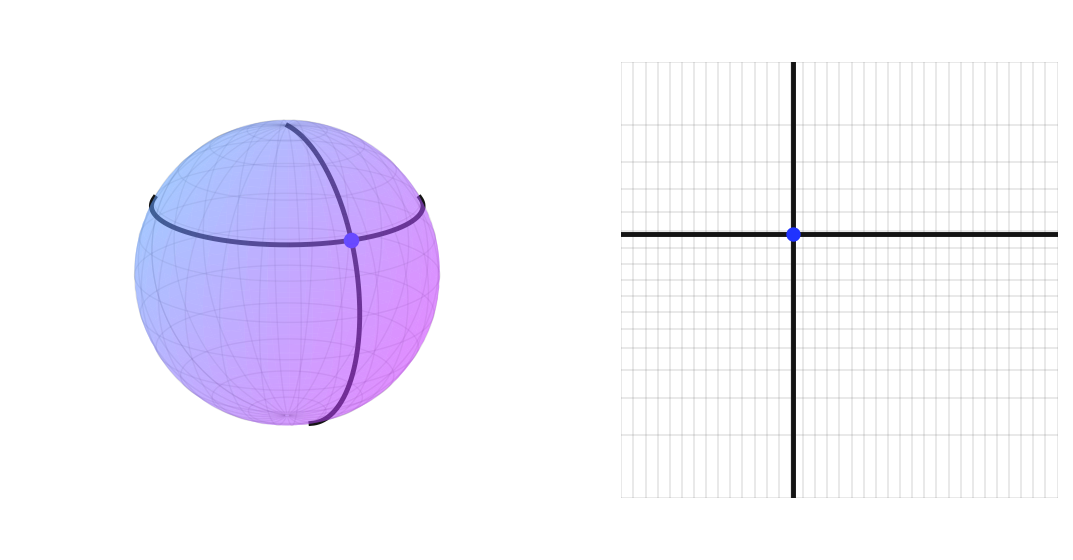

In [12]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Helpers
# ============================================================

deg = np.deg2rad

def sph_to_xyz(lon, lat, R=1.0):
    x = R * np.cos(lat) * np.cos(lon)
    y = R * np.cos(lat) * np.sin(lon)
    z = R * np.sin(lat)
    return x, y, z

def mercator_y(lat):
    lat = np.clip(lat, deg(-85), deg(85))
    return np.log(np.tan(np.pi / 4 + lat / 2))

def camera_vector(elev_deg, azim_deg):
    """
    Approximate vector from origin toward the viewer
    for Matplotlib's elev/azim convention.
    """
    el = np.deg2rad(elev_deg)
    az = np.deg2rad(azim_deg)
    v = np.array([
        np.cos(el) * np.cos(az),
        np.cos(el) * np.sin(az),
        np.sin(el)
    ])
    return v / np.linalg.norm(v)

def visible_mask(x, y, z, elev_deg, azim_deg):
    """
    A point p on the sphere is front-facing if p·v > 0,
    where v points toward the viewer.
    """
    v = camera_vector(elev_deg, azim_deg)
    dots = x * v[0] + y * v[1] + z * v[2]
    return dots >= 0

def plot_visible_curve(ax, x, y, z, elev_deg, azim_deg, **kwargs):
    """
    Plot only the visible portions of a 3D curve on the sphere.
    """
    mask = visible_mask(x, y, z, elev_deg, azim_deg)

    start = None
    for i, m in enumerate(mask):
        if m and start is None:
            start = i
        elif not m and start is not None:
            if i - start > 1:
                ax.plot(x[start:i], y[start:i], z[start:i], **kwargs)
            start = None

    if start is not None and len(x) - start > 1:
        ax.plot(x[start:], y[start:], z[start:], **kwargs)


# ============================================================
# Parameters
# ============================================================

R = 1.0

# Highlighted point / curves
lat_p = deg(28)     # moved higher
lon_p = deg(-38)

# 3D view
elev = 18
azim = -65


# ============================================================
# Figure layout
# ============================================================

fig = plt.figure(figsize=(8.4, 4.8), dpi=160)
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 0.95], wspace=0.16)

ax3d = fig.add_subplot(gs[0, 0], projection="3d")
ax2d = fig.add_subplot(gs[0, 1])


# ============================================================
# Left panel: 3D globe
# ============================================================

# Sphere surface
u = np.linspace(0, 2 * np.pi, 220)
v = np.linspace(-np.pi / 2, np.pi / 2, 140)
U, V = np.meshgrid(u, v)

Xs = np.cos(V) * np.cos(U)
Ys = np.cos(V) * np.sin(U)
Zs = np.sin(V)

# Soft pastel coloring
C = 0.58 + 0.18 * Xs - 0.10 * Zs
facecols = plt.cm.cool(C)

ax3d.plot_surface(
    Xs, Ys, Zs,
    facecolors=facecols,
    linewidth=0,
    antialiased=True,
    alpha=0.34,
    shade=False
)

# Light graticule
grid_color = (0.28, 0.28, 0.28, 0.13)

# Meridians
lat_vals = np.linspace(-np.pi / 2 + 0.02, np.pi / 2 - 0.02, 500)
for lam in deg(np.arange(-180, 181, 15)):
    x, y, z = sph_to_xyz(np.full_like(lat_vals, lam), lat_vals, R=R)
    ax3d.plot(x, y, z, color=grid_color, lw=0.6)

# Parallels
lon_vals = np.linspace(-np.pi, np.pi, 700)
for phi in deg(np.arange(-75, 76, 15)):
    x, y, z = sph_to_xyz(lon_vals, np.full_like(lon_vals, phi), R=R)
    ax3d.plot(x, y, z, color=grid_color, lw=0.6)

# Highlighted latitude: only visible part
lon_vals_bold = np.linspace(-np.pi, np.pi, 1200)
x, y, z = sph_to_xyz(lon_vals_bold, np.full_like(lon_vals_bold, lat_p), R=R)
plot_visible_curve(ax3d, x, y, z, elev, azim, color="0.08", lw=2.2)

# Highlighted longitude: only visible part
lat_vals_bold = np.linspace(-np.pi / 2 + 0.01, np.pi / 2 - 0.01, 1200)
x, y, z = sph_to_xyz(np.full_like(lat_vals_bold, lon_p), lat_vals_bold, R=R)
plot_visible_curve(ax3d, x, y, z, elev, azim, color="0.08", lw=2.2)

# Highlighted point
xp, yp, zp = sph_to_xyz(lon_p, lat_p, R=R)
if visible_mask(np.array([xp]), np.array([yp]), np.array([zp]), elev, azim)[0]:
    ax3d.scatter([xp], [yp], [zp], color="#1f33ff", s=36)

# Clean 3D appearance
ax3d.set_box_aspect((1, 1, 1))
ax3d.view_init(elev=elev, azim=azim)
ax3d.set_xlim(-1.03, 1.03)
ax3d.set_ylim(-1.03, 1.03)
ax3d.set_zlim(-1.03, 1.03)
ax3d.set_axis_off()


# ============================================================
# Right panel: Mercator image
# ============================================================

ymin = mercator_y(deg(-80))
ymax = mercator_y(deg(80))

# Graticule
for lam in deg(np.arange(-180, 181, 10)):
    ax2d.plot([lam, lam], [ymin, ymax], color="0.45", alpha=0.20, lw=0.7)

for phi in deg(np.arange(-80, 81, 10)):
    y = mercator_y(phi)
    ax2d.plot([deg(-180), deg(180)], [y, y], color="0.45", alpha=0.20, lw=0.7)

# Bold latitude and longitude
yp = mercator_y(lat_p)
ax2d.plot([deg(-180), deg(180)], [yp, yp], color="0.08", lw=2.2)
ax2d.plot([lon_p, lon_p], [ymin, ymax], color="0.08", lw=2.2)

# Blue point
ax2d.scatter([lon_p], [yp], color="#1f33ff", s=30, zorder=5)

ax2d.set_xlim(deg(-180), deg(180))
ax2d.set_ylim(ymin, ymax)
ax2d.set_box_aspect(1)
ax2d.axis("off")


# ============================================================
# Export / show
# ============================================================

fig.savefig("Figure8.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
fig.savefig("Figure8.pdf", bbox_inches="tight", pad_inches=0.03)

plt.show()

## Figure 9

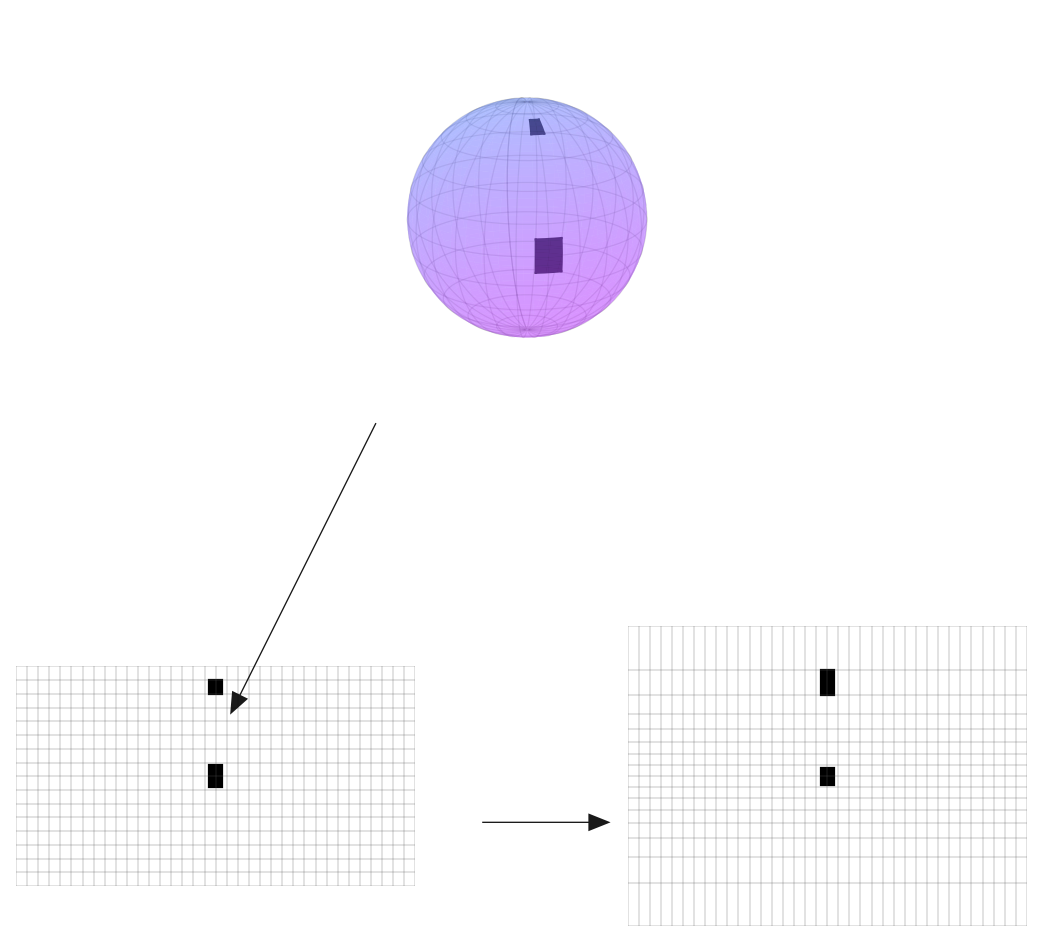

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


# ============================================================
# Helpers
# ============================================================

deg = np.deg2rad

def sph_to_xyz(lon, lat, R=1.0):
    x = R * np.cos(lat) * np.cos(lon)
    y = R * np.cos(lat) * np.sin(lon)
    z = R * np.sin(lat)
    return x, y, z

def mercator_y(lat):
    lat = np.clip(lat, deg(-85), deg(85))
    return np.log(np.tan(np.pi / 4 + lat / 2))

def camera_vector(elev_deg, azim_deg):
    el = np.deg2rad(elev_deg)
    az = np.deg2rad(azim_deg)
    v = np.array([
        np.cos(el) * np.cos(az),
        np.cos(el) * np.sin(az),
        np.sin(el)
    ])
    return v / np.linalg.norm(v)

def visible_mask(x, y, z, elev_deg, azim_deg):
    v = camera_vector(elev_deg, azim_deg)
    dots = x * v[0] + y * v[1] + z * v[2]
    return dots >= 0

def plot_visible_curve(ax, x, y, z, elev_deg, azim_deg, **kwargs):
    mask = visible_mask(x, y, z, elev_deg, azim_deg)

    start = None
    for i, m in enumerate(mask):
        if m and start is None:
            start = i
        elif not m and start is not None:
            if i - start > 1:
                ax.plot(x[start:i], y[start:i], z[start:i], **kwargs)
            start = None

    if start is not None and len(x) - start > 1:
        ax.plot(x[start:], y[start:], z[start:], **kwargs)

def draw_spherical_patch(
    ax, lon1, lon2, lat1, lat2, elev, azim,
    R=1.0, color="black", alpha=1.0,
    nlon=60, nlat=40, edge_lw=1.0
):
    lon = np.linspace(lon1, lon2, nlon)
    lat = np.linspace(lat1, lat2, nlat)
    LON, LAT = np.meshgrid(lon, lat)

    X, Y, Z = sph_to_xyz(LON, LAT, R=R)
    vis = visible_mask(X, Y, Z, elev, azim)

    Xp = np.where(vis, X, np.nan)
    Yp = np.where(vis, Y, np.nan)
    Zp = np.where(vis, Z, np.nan)

    ax.plot_surface(
        Xp, Yp, Zp,
        color=color,
        alpha=alpha,
        linewidth=0,
        shade=False,
        antialiased=False
    )

    t = np.linspace(0, 1, 500)

    lon_b = lon1 + (lon2 - lon1) * t
    lat_b = np.full_like(t, lat1)
    x, y, z = sph_to_xyz(lon_b, lat_b, R=R)
    plot_visible_curve(ax, x, y, z, elev, azim, color=color, lw=edge_lw)

    lon_t = lon1 + (lon2 - lon1) * t
    lat_t = np.full_like(t, lat2)
    x, y, z = sph_to_xyz(lon_t, lat_t, R=R)
    plot_visible_curve(ax, x, y, z, elev, azim, color=color, lw=edge_lw)

    lon_l = np.full_like(t, lon1)
    lat_l = lat1 + (lat2 - lat1) * t
    x, y, z = sph_to_xyz(lon_l, lat_l, R=R)
    plot_visible_curve(ax, x, y, z, elev, azim, color=color, lw=edge_lw)

    lon_r = np.full_like(t, lon2)
    lat_r = lat1 + (lat2 - lat1) * t
    x, y, z = sph_to_xyz(lon_r, lat_r, R=R)
    plot_visible_curve(ax, x, y, z, elev, azim, color=color, lw=edge_lw)


# ============================================================
# Parameters
# ============================================================

R = 1.0

# Rotate only slightly away from straight-on
elev = 18
azim = -10

# Same meridian bounds for both regions, slightly off the front center
lon1 = deg(-6)
lon2 = deg(6)

# Equatorial region
lat1_eq = deg(-8)
lat2_eq = deg(8)

# Northern region moved 10 degrees south: now 60 to 70 N
lat1_hi = deg(60)
lat2_hi = deg(70)


# ============================================================
# Figure layout
# ============================================================

fig = plt.figure(figsize=(7.8, 7.2), dpi=160)

# Repositioned for better balance
ax_globe = fig.add_axes([0.29, 0.55, 0.39, 0.36], projection="3d")
ax_eq    = fig.add_axes([0.08, 0.12, 0.32, 0.26])
ax_merc  = fig.add_axes([0.57, 0.12, 0.32, 0.26])


# ============================================================
# Top: 3D globe
# ============================================================

u = np.linspace(0, 2 * np.pi, 220)
v = np.linspace(-np.pi / 2, np.pi / 2, 140)
U, V = np.meshgrid(u, v)

Xs = np.cos(V) * np.cos(U)
Ys = np.cos(V) * np.sin(U)
Zs = np.sin(V)

C = 0.58 + 0.18 * Xs - 0.10 * Zs
facecols = plt.cm.cool(C)

ax_globe.plot_surface(
    Xs, Ys, Zs,
    facecolors=facecols,
    linewidth=0,
    antialiased=True,
    alpha=0.34,
    shade=False
)

grid_color = (0.20, 0.20, 0.20, 0.16)

lat_vals = np.linspace(-np.pi / 2 + 0.02, np.pi / 2 - 0.02, 500)
for lam in deg(np.arange(-180, 181, 15)):
    x, y, z = sph_to_xyz(np.full_like(lat_vals, lam), lat_vals, R)
    ax_globe.plot(x, y, z, color=grid_color, lw=0.55)

lon_vals = np.linspace(-np.pi, np.pi, 600)
for phi in deg(np.arange(-75, 76, 15)):
    x, y, z = sph_to_xyz(lon_vals, np.full_like(lon_vals, phi), R)
    ax_globe.plot(x, y, z, color=grid_color, lw=0.55)

draw_spherical_patch(
    ax_globe, lon1, lon2, lat1_eq, lat2_eq, elev, azim,
    R=R, color="black", alpha=1.0, edge_lw=1.0
)
draw_spherical_patch(
    ax_globe, lon1, lon2, lat1_hi, lat2_hi, elev, azim,
    R=R, color="black", alpha=1.0, edge_lw=1.0
)

ax_globe.set_box_aspect((1, 1, 1))
ax_globe.view_init(elev=elev, azim=azim)
ax_globe.set_xlim(-1.03, 1.03)
ax_globe.set_ylim(-1.03, 1.03)
ax_globe.set_zlim(-1.03, 1.03)
ax_globe.set_axis_off()


# ============================================================
# Bottom-left: equirectangular
# ============================================================

for lam in deg(np.arange(-180, 181, 10)):
    ax_eq.plot([lam, lam], [deg(-80), deg(80)], color="0.35", alpha=0.22, lw=0.7)
for phi in deg(np.arange(-80, 81, 10)):
    ax_eq.plot([deg(-180), deg(180)], [phi, phi], color="0.35", alpha=0.22, lw=0.7)

for (a1, a2) in [(lat1_eq, lat2_eq), (lat1_hi, lat2_hi)]:
    rect = plt.Rectangle(
        (lon1, a1), lon2 - lon1, a2 - a1,
        facecolor="black", edgecolor="black"
    )
    ax_eq.add_patch(rect)

ax_eq.set_xlim(deg(-180), deg(180))
ax_eq.set_ylim(deg(-80), deg(80))
ax_eq.set_box_aspect(0.55)
ax_eq.axis("off")


# ============================================================
# Bottom-right: Mercator
# ============================================================

ymin = mercator_y(deg(-80))
ymax = mercator_y(deg(80))

for lam in deg(np.arange(-180, 181, 10)):
    ax_merc.plot([lam, lam], [ymin, ymax], color="0.35", alpha=0.22, lw=0.7)
for phi in deg(np.arange(-80, 81, 10)):
    y = mercator_y(phi)
    ax_merc.plot([deg(-180), deg(180)], [y, y], color="0.35", alpha=0.22, lw=0.7)

for (a1, a2) in [(lat1_eq, lat2_eq), (lat1_hi, lat2_hi)]:
    y1 = mercator_y(a1)
    y2 = mercator_y(a2)
    rect = plt.Rectangle(
        (lon1, y1), lon2 - lon1, y2 - y1,
        facecolor="black", edgecolor="black"
    )
    ax_merc.add_patch(rect)

ax_merc.set_xlim(deg(-180), deg(180))
ax_merc.set_ylim(ymin, ymax)
ax_merc.set_box_aspect(0.75)
ax_merc.axis("off")


# ============================================================
# Figure-level arrows
# ============================================================

# Start just below-left of the sphere, closer to its visible placement
arrow1 = FancyArrowPatch(
    (0.37, 0.56), (0.25, 0.30),
    transform=fig.transFigure,
    arrowstyle="Simple,head_width=8,head_length=10,tail_width=0.6",
    color="black",
    lw=0.0,
    alpha=0.9
)
fig.add_artist(arrow1)

arrow2 = FancyArrowPatch(
    (0.45, 0.21), (0.56, 0.21),
    transform=fig.transFigure,
    arrowstyle="Simple,head_width=8,head_length=10,tail_width=0.6",
    color="black",
    lw=0.0,
    alpha=0.9
)
fig.add_artist(arrow2)


# ============================================================
# Save / show
# ============================================================

fig.savefig("Figure9.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
fig.savefig("Figure9.pdf", bbox_inches="tight", pad_inches=0.03)

plt.show()